In [1]:
!pip install -qU roboflow ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 51.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 65.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 117.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.2.0 which is incompatible.


In [2]:
from roboflow import Roboflow
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()

rf = Roboflow(api_key=user_secrets.get_secret("roboflow"))
project = rf.workspace("mohammeds-workspace-f4ato").project("road-damage-detection-india-avj3c")
dataset = project.version(1).download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Road-Damage-Detection-India-1 in yolov8:: 100%|██████████| 15417/15417 [00:01<00:00, 8415.36it/s] 


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Ultralytics 8.4.37 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                       CUDA:1 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/Road-Damage-Detection-India-1/data.yaml, degrees=15.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.

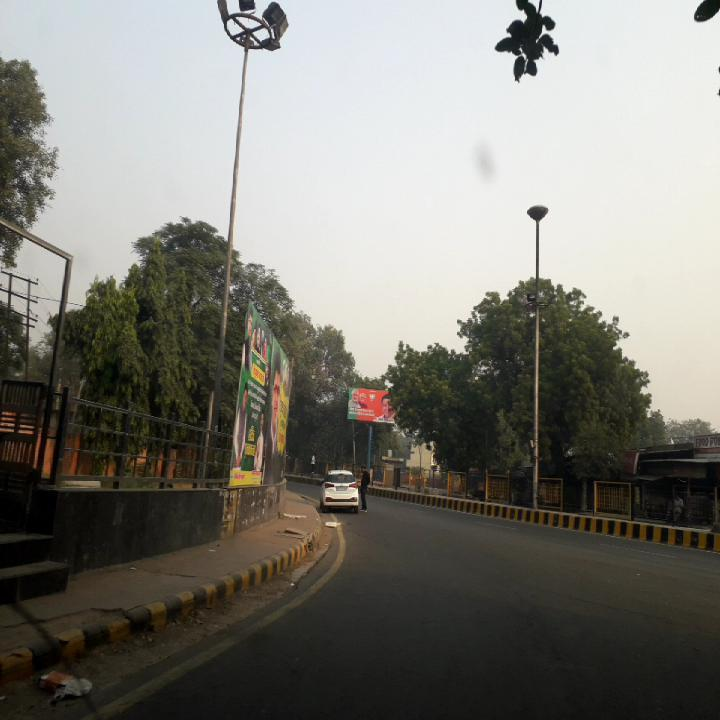

In [3]:
from ultralytics import YOLO

model = YOLO("yolo26s.pt")

train_results = model.train(
    data="/kaggle/working/Road-Damage-Detection-India-1/data.yaml",
    epochs=100,
    imgsz=640,
    device=[0, 1],
    degrees=15.0,     # Rotate
    flipud=0.5,       # Flip up-down
    mosaic=1.0,       # 4-image mosaic
    mixup=0.1,        # Blend images
    erasing=0.4       # Random erasing

)

metrics = model.val()

results = model("/kaggle/working/Road-Damage-Detection-India-1/valid/images/India_000012_jpg.rf.f6f8e3069c798dd1404bde38f655bf76.jpg")
results[0].show()



In [4]:
# Export the model to ONNX format for deployment
# path = model.export(format="onnx")  # Returns the path to the exported model

In [5]:
!cp ./runs/detect/train/weights/best.pt ./best.pt
!yolo export model=/kaggle/working/best.pt format=onnx imgsz=640 opset=17 simplify=True

Ultralytics 8.4.37 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO26s summary (fused): 122 layers, 9,468,663 parameters, 0 gradients, 20.5 GFLOPs

PyTorch: starting from '/kaggle/working/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (19.4 MB)
requirements: Ultralytics requirements ['onnxslim>=0.1.71', 'onnxruntime'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 12 packages in 274ms
 Downloaded onnxruntime
Prepared 2 packages in 281ms
Installed 2 packages in 11ms
 + onnxruntime==1.24.4
 + onnxslim==0.1.91

requirements: AutoUpdate success ✅ 1.0s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.20.1 opset 17...
/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/torchscri